In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/Colab Notebooks/tabla de datos.xlsx'

df = pd.read_excel(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,country,year,pobl_0-19,pobl_20-39,pobl_40-59,pobl_+60,pobl_total,esper_de_vida,pib_pcapita,mortalidad_inf_niño (0-5 años)/1000,...,tasa_pobreza_extrema,reservas_totales_%_de_la_deuda_externa_total,%_pib_gasto_publ_en_secundaria_/estudiante,%_inflacion_anual,%_usuarios_internet,asesinatos/100k_personas,consumo_petroleo_pcapita,suicidios/100K_personas,gasto_publ_total_en_salud_% _pib,muertes_accidente_tráfico/100K_personas
0,Argentina,1950,3530000,5530000,3470000,1180000,13710000,63.3,9450.0,93.6,...,0.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,1951,3570000,5620000,3560000,1220000,13970000,63.5,9680.0,92.0,...,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,1952,3610000,5700000,3650000,1270000,14230000,64.2,9020.0,88.8,...,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,1953,3650000,5770000,3740000,1320000,14480000,64.1,9340.0,85.7,...,0.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,1954,3700000,5830000,3840000,1380000,14750000,64.7,9560.0,81.2,...,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**TRATAMIENTO DATOS FALTANTES**

- % EMIGRANTES E IMMIGRANTES: IMPUTACIÓN POR INTERPOLACIÓN LINEAL

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

df_nuevo = df.copy()

columnas_temporales = ['% _emigrantes', '%_ inmgirantes']

for col in columnas_temporales:
    df_nuevo[col] = df.groupby('country')[col].transform(lambda grupo: grupo.interpolate(method='linear'))

In [ ]:
for col in columnas_temporales:
    df_nuevo[col] = df.groupby("country")[col].transform(
        lambda grupo: grupo.interpolate(method='linear').bfill().ffill()
    )

In [ ]:
columnas_a_eliminar = [
    'suicidios_por_100K_personas',
    'asesinatos/100k_personas',
    'muertes_accidente_tráfico_por_100K_personas'
]

df_nuevo = df_nuevo.drop(columns=columnas_a_eliminar)

In [ ]:
variable = '%_pib_gasto_publ_en_secundaria_por_estudiante'

df.groupby('country')[variable].apply(lambda x: x.notnull().sum())

,%_pib_gasto_publ_en_secundaria_por_estudiante
country,
Argentina,20
China,1
Germany,12
India,12
Nigeria,0
Russia,0
Spain,19
USA,7


In [ ]:
df_nuevo = df_nuevo.drop(columns=['%_pib_gasto_publ_en_secundaria_por_estudiante'])

print('%_pib_gasto_publ_en_secundaria_por_estudiante' in df_nuevo.columns)

False


In [ ]:
columna = 'nivel_de_felicidad'

for pais in df_nuevo['country'].unique():
    datos = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].notnull())]
    faltantes = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].isnull())]

    if len(datos) >= 2 and not faltantes.empty:
        modelo = LinearRegression()
        modelo.fit(datos[['year']], datos[columna])
        pred = modelo.predict(faltantes[['year']])
        df_nuevo.loc[faltantes.index, columna] = pred

df_nuevo = df_nuevo.drop(columns=['reservas_totales_%_de_la_deuda_externa_total'])

In [ ]:
df_trabajo = df_nuevo.copy()
columna = 'gasto_publ_total_en_salud_% _pib '

def imputar_faltantes_regresion(grupo):
    datos = grupo.dropna(subset=[columna])
    if len(datos) >= 5:
        modelo = LinearRegression()
        X_entreno = datos[['year']]
        y_entreno = datos[columna]
        modelo.fit(X_entreno, y_entreno)

        faltantes = grupo[columna].isnull()
        if faltantes.any():
            grupo.loc[faltantes, columna] = modelo.predict(grupo.loc[faltantes, ['year']])
    return grupo

df_nuevo = df_nuevo.groupby("country", group_keys=False).apply(imputar_faltantes_regresion)

faltantes_restantes = df_nuevo[columna].isnull().sum()

<ipython-input-11-3065089527>:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nuevo = df_nuevo.groupby("country", group_keys=False).apply(imputar_faltantes_regresion)


In [ ]:
df_trabajo = df_nuevo.copy()
columna = 'consumo_petroleo_pcapita'

def imputar_regresion_petroleo(grupo):
    datos = grupo.dropna(subset=[columna])
    if len(datos) >= 5:
        modelo = LinearRegression()
        X = datos[['year']]
        y = datos[columna]
        modelo.fit(X, y)

        nan_mask = grupo[columna].isnull()
        grupo.loc[nan_mask, columna] = modelo.predict(grupo.loc[nan_mask, ['year']])
    return grupo

df_nuevo = df_trabajo.groupby("country", group_keys=False).apply(imputar_regresion_petroleo)

faltantes_petroleo = df_nuevo[columna].isnull().sum()
print(f"Faltantes restantes en '{columna}': {faltantes_petroleo}")


Faltantes restantes en 'consumo_petroleo_pcapita': 32


<ipython-input-12-267829161>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nuevo = df_trabajo.groupby("country", group_keys=False).apply(imputar_regresion_petroleo)


In [ ]:
columna = 'Co2_pcap_toneladas'

df_nuevo[columna] = df_nuevo.groupby("country")[columna].transform(
    lambda grupo: grupo.fillna(grupo.mean())
)


In [ ]:
columna = '%_usuarios_internet'

for pais in df_nuevo['country'].unique():
    media = df_nuevo.loc[df_nuevo['country'] == pais, columna].mean()
    df_nuevo.loc[(df_nuevo['country'] == pais) & (df_nuevo[columna].isnull()), columna] = media



In [ ]:
columna = '%_usuarios_internet'

for pais in df_nuevo['country'].unique():
    datos = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].notnull())]
    faltantes = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].isnull())]

    if len(datos) >= 2 and not faltantes.empty:
        modelo = LinearRegression()
        modelo.fit(datos[['year']], datos[columna])
        pred = modelo.predict(faltantes[['year']])
        df_nuevo.loc[faltantes.index, columna] = pred


In [ ]:
columna = '%_inflacion_anual'

for pais in df_nuevo['country'].unique():
    datos = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].notnull())]
    faltantes = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].isnull())]

    if len(datos) >= 2 and not faltantes.empty:
        modelo = LinearRegression()
        modelo.fit(datos[['year']], datos[columna])
        pred = modelo.predict(faltantes[['year']])
        df_nuevo.loc[faltantes.index, columna] = pred


In [ ]:
variables = ['%_trabaj_agricult', '%_trabaj_servicios', '%_trabaj_industria']

for columna in variables:
    for pais in df_nuevo['country'].unique():
        datos = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].notnull())]
        faltantes = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].isnull())]

        if len(datos) >= 2 and not faltantes.empty:
            modelo = LinearRegression()
            modelo.fit(datos[['year']], datos[columna])
            pred = modelo.predict(faltantes[['year']])
            df_nuevo.loc[faltantes.index, columna] = pred


In [ ]:
variables = ['%_importaciones_pib', '%_inversiones_pib']

for columna in variables:
    for pais in df_nuevo['country'].unique():
        datos = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].notnull())]
        faltantes = df_nuevo[(df_nuevo['country'] == pais) & (df_nuevo[columna].isnull())]

        if len(datos) >= 2 and not faltantes.empty:
            modelo = LinearRegression()
            modelo.fit(datos[['year']], datos[columna])
            pred = modelo.predict(faltantes[['year']])
            df_nuevo.loc[faltantes.index, columna] = pred


In [ ]:
df_nuevo.to_excel('tabla_de_datos_sin_faltantes.xlsx', index=False)
ruta = '/content/drive/MyDrive/Colab Notebooks/tabla_de_datos_sin_faltantes.xlsx'
df_nuevo.to_excel(ruta, index=False)

In [ ]:
nueva_ruta = '/content/drive/MyDrive/Colab Notebooks/tabla_de_datos_sin_faltantes.xlsx'
df_nuevo = pd.read_excel(nueva_ruta)

variables = df_nuevo.select_dtypes(include='number').columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

datos_escalados = scaler.fit_transform(df_nuevo[variables])

df_escalado = pd.DataFrame(datos_escalados, columns=variables)

df_escalado['country'] = df_nuevo['country'].values
df_escalado['year'] = df_nuevo['year'].values

df_escalado.to_excel('tabla_de_datos_sin_faltantes.xlsx', index=False)
ruta = '/content/drive/MyDrive/Colab Notebooks/tabla_de_datos_normalizado.xlsx'
df_escalado.to_excel(ruta, index=False)

## PCA (Análisis de Componentes Principales)

In [ ]:
ruta = '/content/drive/MyDrive/Colab Notebooks/tabla_de_datos_normalizado.xlsx'

df_norm = pd.read_excel(ruta)


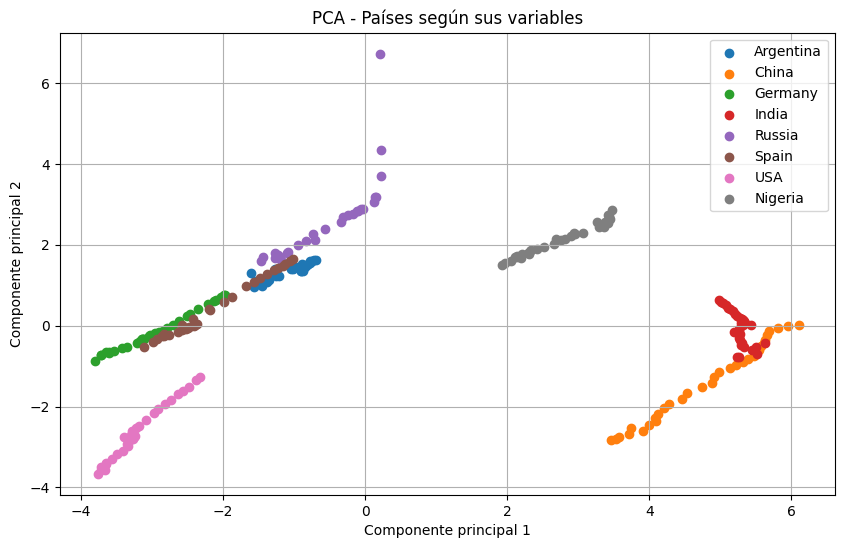

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

variables_numericas = df_escalado.select_dtypes(include='number').drop(columns=['year'], errors='ignore')

X_sin_nigeria = variables_numericas[df_escalado['country'] != 'Nigeria']
X_nigeria = variables_numericas[df_escalado['country'] == 'Nigeria']

columnas_validas = X_nigeria.dropna(axis=1).columns
X_sin_nigeria_validas = X_sin_nigeria[columnas_validas]
X_nigeria_validas = X_nigeria[columnas_validas]

pca = PCA(n_components=2)
componentes_sin_nigeria = pca.fit_transform(X_sin_nigeria_validas)
componentes_nigeria = pca.transform(X_nigeria_validas)

df_pca_sin_nigeria = pd.DataFrame(componentes_sin_nigeria, columns=['PC1', 'PC2'])
df_pca_sin_nigeria['country'] = df_escalado[df_escalado['country'] != 'Nigeria']['country'].values

df_pca_nigeria = pd.DataFrame(componentes_nigeria, columns=['PC1', 'PC2'])
df_pca_nigeria['country'] = 'Nigeria'

df_pca_todo = pd.concat([df_pca_sin_nigeria, df_pca_nigeria], ignore_index=True)

plt.figure(figsize=(10, 6))
for pais in df_pca_todo['country'].unique():
    puntos = df_pca_todo[df_pca_todo['country'] == pais]
    plt.scatter(puntos['PC1'], puntos['PC2'], label=pais)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('PCA - Países según sus variables')
plt.legend()
plt.grid(True)
plt.show()


# *** ANÁLISIS  GRÁFICO ***

In [ ]:
ruta = '/content/drive/MyDrive/Colab Notebooks/tabla_de_datos_sin_faltantes.xlsx'

df = pd.read_excel(ruta)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

dfs_por_pais = {pais: grupo for pais, grupo in df.groupby('country')}
sns.set(style="white", font_scale=0.9)

for pais, df_pais in dfs_por_pais.items():

    df_numerico = df_pais.select_dtypes(include='number')

    corr = df_numerico.corr()

    plt.figure(figsize=(20, 20))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title(f'Mapa de Correlaciones: {pais}')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# 1. Demografía y estructura de población

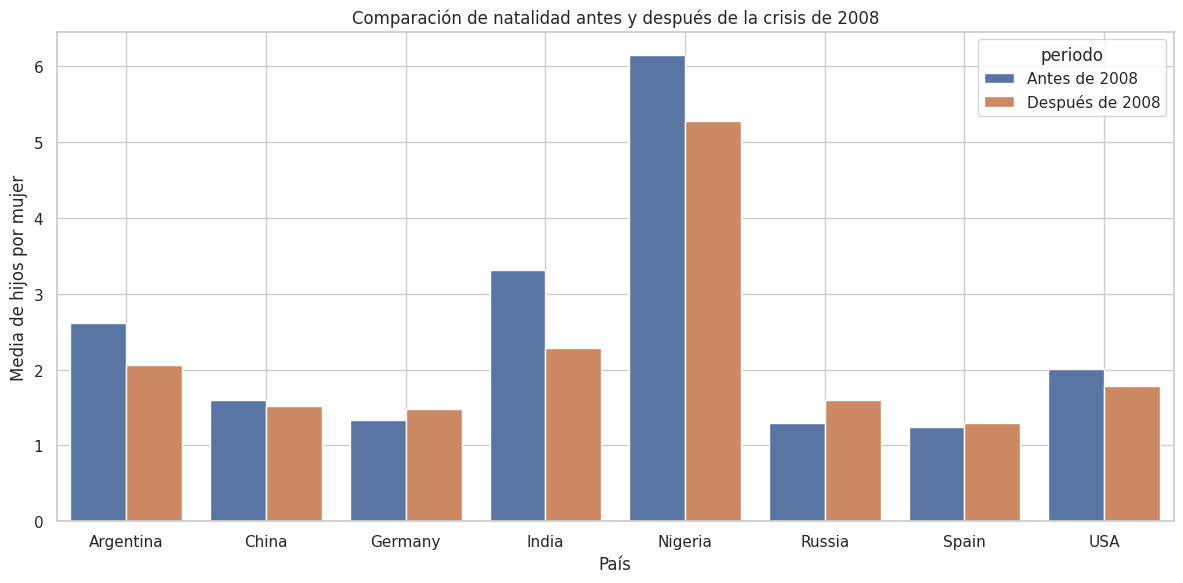

In [ ]:
df['periodo'] = df['year'].apply(lambda x: 'Antes de 2008' if x < 2008 else 'Después de 2008')

df_medias = df.groupby(['country', 'periodo'])['hijos_por_mujer_fertil_total'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_medias, x='country', y='hijos_por_mujer_fertil_total', hue='periodo')
plt.title("Comparación de natalidad antes y después de la crisis de 2008")
plt.xlabel("País")
plt.ylabel("Media de hijos por mujer")
plt.grid(True)
plt.tight_layout()
plt.show()

# RELACIÓN ENTRE ESTRUCTURA LABORAL Y ECONOMÍA

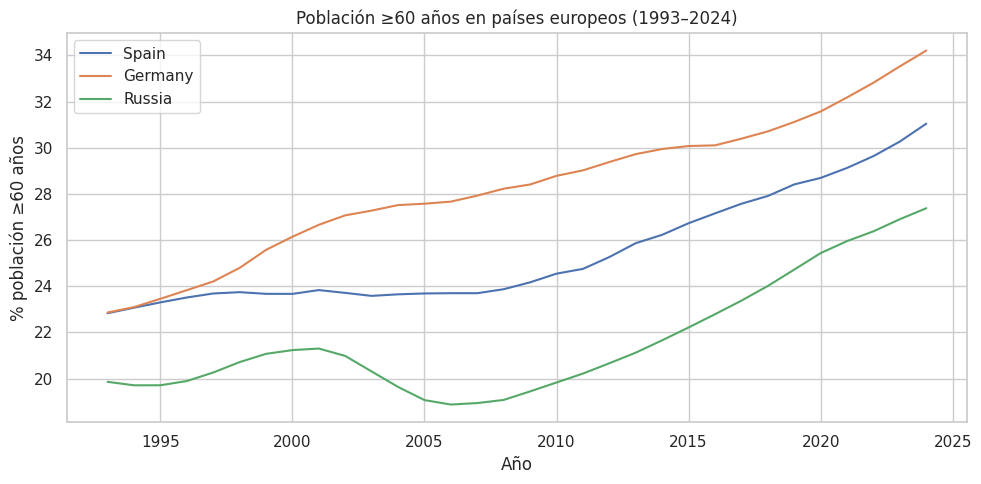

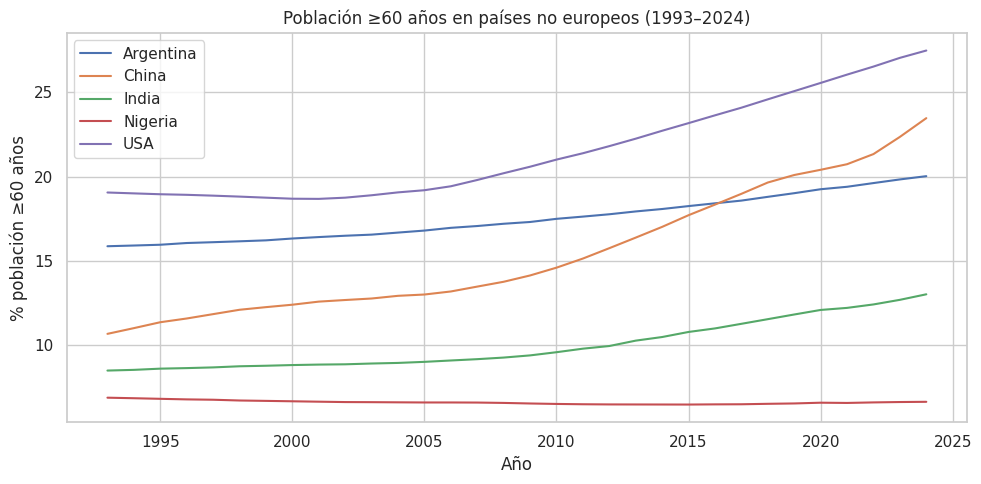

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


df['pobl_+60_pct'] = df['pobl_+60'] / df['pobl_total'] * 100

paises_europeos = ['Spain', 'Germany', 'Russia']
df_europeos = df[df['country'].isin(paises_europeos)].copy()
df_europeos_grouped = df_europeos.groupby(['year', 'country'])['pobl_+60_pct'].mean().reset_index()

plt.figure(figsize=(10, 5))
for pais in paises_europeos:
    datos = df_europeos_grouped[df_europeos_grouped['country'] == pais]
    plt.plot(datos['year'], datos['pobl_+60_pct'], label=pais)

plt.title("Población ≥60 años en países europeos (1993–2024)")
plt.xlabel("Año")
plt.ylabel("% población ≥60 años")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

paises_no_europeos = ['Argentina', 'China', 'India', 'Nigeria', 'USA']
df_no_europeos = df[df['country'].isin(paises_no_europeos)].copy()
df_no_europeos['pobl_+60_pct'] = df_no_europeos['pobl_+60'] / df_no_europeos['pobl_total'] * 100
df_no_europeos_grouped = df_no_europeos.groupby(['year', 'country'])['pobl_+60_pct'].mean().reset_index()

plt.figure(figsize=(10, 5))
for pais in paises_no_europeos:
    datos = df_no_europeos_grouped[df_no_europeos_grouped['country'] == pais]
    plt.plot(datos['year'], datos['pobl_+60_pct'], label=pais)

plt.title("Población ≥60 años en países no europeos (1993–2024)")
plt.xlabel("Año")
plt.ylabel("% población ≥60 años")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


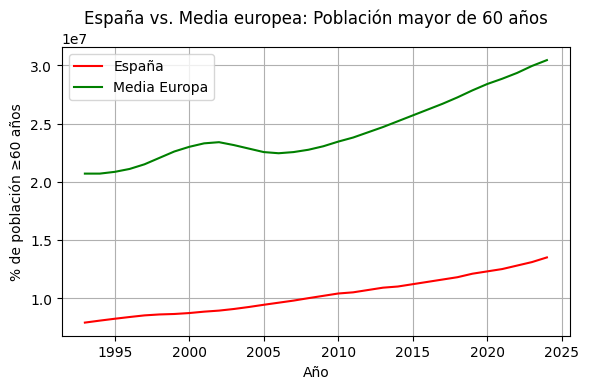

In [ ]:
europa_df = df[df['country'].isin(['Germany', 'Russia'])].groupby('year')['pobl_+60'].mean().reset_index()
esp_df = df[df['country'] == 'Spain'][['year','pobl_+60']]

comp_df = pd.merge(esp_df, europa_df, on='year', suffixes=('_esp','_eur'))

plt.figure(figsize=(6,4))
plt.plot(comp_df['year'], comp_df['pobl_+60_esp'], label='España', color='red')
plt.plot(comp_df['year'], comp_df['pobl_+60_eur'], label='Media Europa', color='green')
plt.xlabel('Año')
plt.ylabel('% de población ≥60 años')
plt.title('España vs. Media europea: Población mayor de 60 años')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


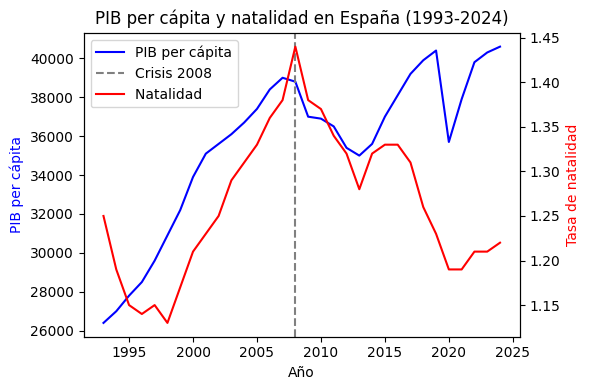

In [ ]:
esp = df[df['country']=='Spain']
fig, ax1 = plt.subplots(figsize=(6,4))
ax2 = ax1.twinx()
ax1.plot(esp['year'], esp['pib_pcapita'], color='blue', label='PIB per cápita')
ax2.plot(esp['year'], esp['hijos_por_mujer_fertil_total'], color='red', label='Natalidad ')
ax1.axvline(x=2008, color='gray', linestyle='--', label='Crisis 2008')
ax1.set_xlabel('Año')
ax1.set_ylabel('PIB per cápita', color='blue')
ax2.set_ylabel('Tasa de natalidad', color='red')
plt.title('PIB per cápita y natalidad en España (1993-2024)')
lineas = ax1.get_lines() + ax2.get_lines()
etiquetas = [ln.get_label() for ln in lineas]
ax1.legend(lineas, etiquetas, loc='upper left')
plt.tight_layout()
plt.show()


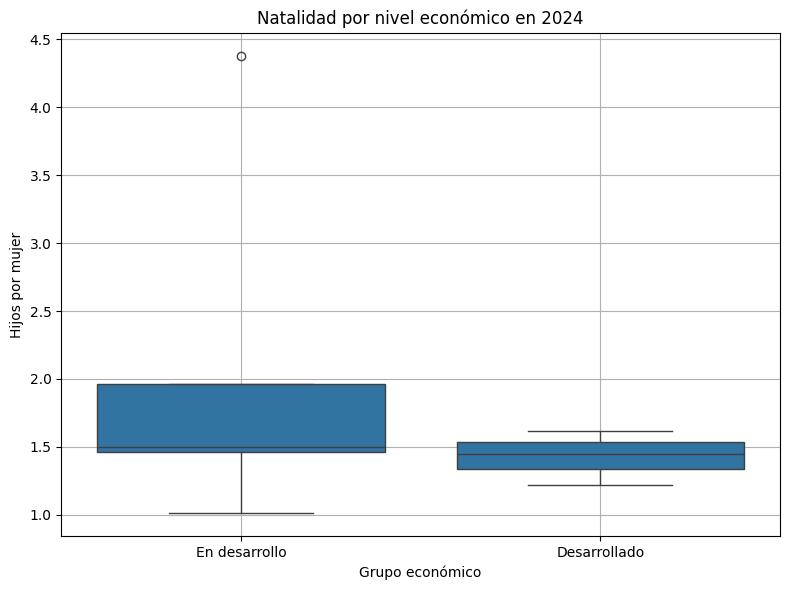

In [ ]:
df_2024 = df[df['year'] == 2024].copy()

df_2024['grupo_economico'] = df_2024['pib_pcapita'].apply(
    lambda x: 'Desarrollado' if x >= 30000 else 'En desarrollo'
)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_2024, x='grupo_economico', y='hijos_por_mujer_fertil_total')
plt.title("Natalidad por nivel económico en 2024")
plt.xlabel("Grupo económico")
plt.ylabel("Hijos por mujer")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
correlaciones = {
    'Agricultura': df['pib_pcapita'].corr(df['%_trabaj_agricult']),
    'Industria': df['pib_pcapita'].corr(df['%_trabaj_industria']),
    'Servicios': df['pib_pcapita'].corr(df['%_trabaj_servicios']),
}

correlaciones_df = pd.DataFrame.from_dict(correlaciones, orient='index', columns=['Correlación con PIB per cápita'])
correlaciones_df.index.name = 'Sector económico'
print(f'{correlaciones}')

{'Agricultura': np.float64(-0.8104000748628986), 'Industria': np.float64(0.3014287074659425), 'Servicios': np.float64(0.796596982685434)}


Columnas del dataframe: ['country', 'year', 'pobl_0-19', 'pobl_20-39', 'pobl_40-59', 'pobl_+60', 'pobl_total', 'esper_de_vida', 'pib_pcapita', 'mortalidad_inf_niño (0-5 años)_por_1000', 'Co2_pcap_toneladas', 'hijos_por_mujer_fertil_total', '%_trabaj_agricult', '%_trabaj_servicios', '%_trabaj_industria', '% _emigrantes', '%_ inmgirantes', 'nivel_de_felicidad', 'ingreso_gasto_promedio_diario_($_por_pers_por_dia)', '%_importaciones_pib', '%_inversiones_pib', 'tasa_pobreza_extrema', '%_inflacion_anual', '%_usuarios_internet', 'consumo_petroleo_pcapita', 'gasto_publ_total_en_salud_% _pib ', 'grupo_pib', 'periodo', 'pobl_+60_pct', 'GDPpc_quartile', 'HealthExp_quartile', 'LifeExp_cat', 'GDPpc_cat']
Correlación PIB vs Agricultura: -0.81
Correlación PIB vs Industria: 0.80
Correlación PIB vs Servicios: 0.30


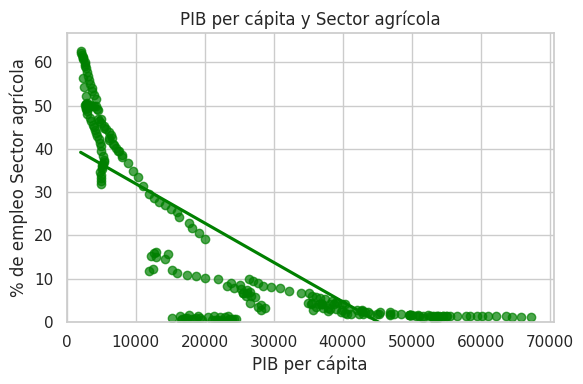

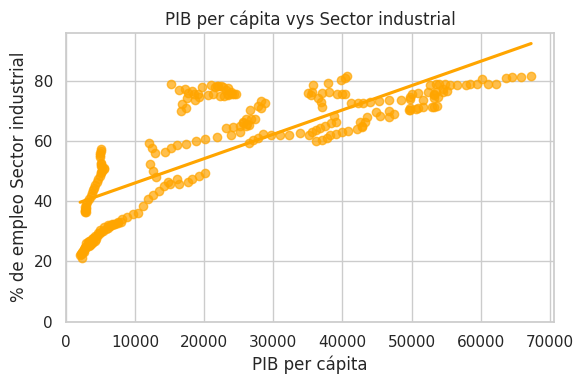

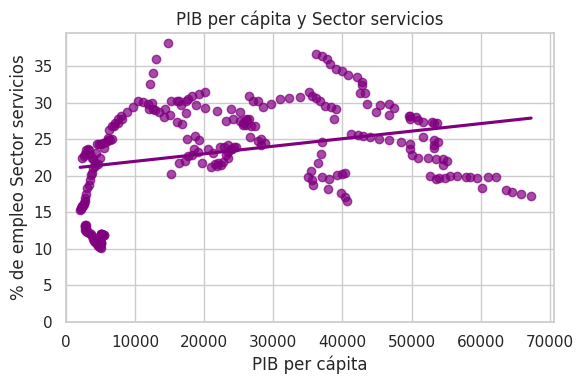

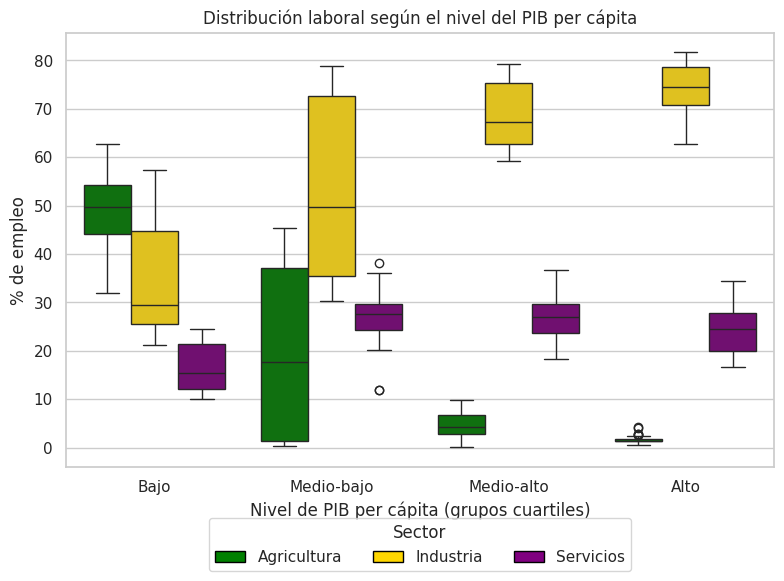

In [47]:
sns.set_theme(style="whitegrid")

print("Columnas del dataframe:", df.columns.tolist())

if '%_trabaj_industria' in df.columns and '%_trabaj_servicios' in df.columns:
    df['__temp'] = df['%_trabaj_industria']
    df['%_trabaj_industria'] = df['%_trabaj_servicios']
    df['%_trabaj_servicios'] = df['__temp']
    df.drop(columns=['__temp'], inplace=True)

corr_agri = df['pib_pcapita'].corr(df['%_trabaj_agricult'])
corr_ind = df['pib_pcapita'].corr(df['%_trabaj_industria'])
corr_serv = df['pib_pcapita'].corr(df['%_trabaj_servicios'])
print(f"Correlación PIB vs Agricultura: {corr_agri:.2f}")
print(f"Correlación PIB vs Industria: {corr_ind:.2f}")
print(f"Correlación PIB vs Servicios: {corr_serv:.2f}")

plt.figure(figsize=(6,4))
sns.regplot(x='pib_pcapita', y='%_trabaj_agricult', data=df, ci=None,
            scatter_kws={'alpha':0.7, 'color':'green'},
            line_kws={'color':'green'})
plt.xlabel("PIB per cápita")
plt.ylabel("% de empleo Sector agrícola")
plt.title("PIB per cápita y Sector agrícola")
plt.ylim(0, None)
plt.xlim(0, None)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.regplot(x='pib_pcapita', y='%_trabaj_industria', data=df, ci=None,
            scatter_kws={'alpha':0.7, 'color':'orange'},
            line_kws={'color':'orange'})
plt.xlabel("PIB per cápita")
plt.ylabel("% de empleo Sector industrial")
plt.title("PIB per cápita vys Sector industrial")
plt.ylim(0, None)
plt.xlim(0, None)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.regplot(x='pib_pcapita', y='%_trabaj_servicios', data=df, ci=None,
            scatter_kws={'alpha':0.7, 'color':'purple'},
            line_kws={'color':'purple'})
plt.xlabel("PIB per cápita")
plt.ylabel("% de empleo Sector servicios")
plt.title("PIB per cápita y Sector servicios")
plt.ylim(0, None)
plt.xlim(0, None)
plt.tight_layout()
plt.show()

df['grupo_pib'] = pd.qcut(df['pib_pcapita'], q=4, labels=["Bajo","Medio-bajo","Medio-alto","Alto"])

df_box = df.melt(id_vars=['country','year','grupo_pib'],
                 value_vars=['%_trabaj_agricult','%_trabaj_industria','%_trabaj_servicios'],
                 var_name='sector', value_name='porc_empleo')
df_box['sector'] = df_box['sector'].replace({
    '%_trabaj_agricult': 'Agricultura',
    '%_trabaj_industria': 'Industria',
    '%_trabaj_servicios': 'Servicios'
})

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(x='grupo_pib', y='porc_empleo', hue='sector', data=df_box,
            order=["Bajo","Medio-bajo","Medio-alto","Alto"],
            hue_order=["Agricultura","Industria","Servicios"],
            palette={'Agricultura':'green','Industria':'gold','Servicios':'purple'},
            ax=ax)
ax.set_xlabel("Nivel de PIB per cápita (grupos cuartiles)")
ax.set_ylabel("% de empleo")
ax.set_title("Distribución laboral según el nivel del PIB per cápita")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Agricultura'),
    Patch(facecolor='gold', edgecolor='black', label='Industria'),
    Patch(facecolor='purple', edgecolor='black', label='Servicios')
]
ax.legend(handles=legend_elements, title="Sector", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.show()




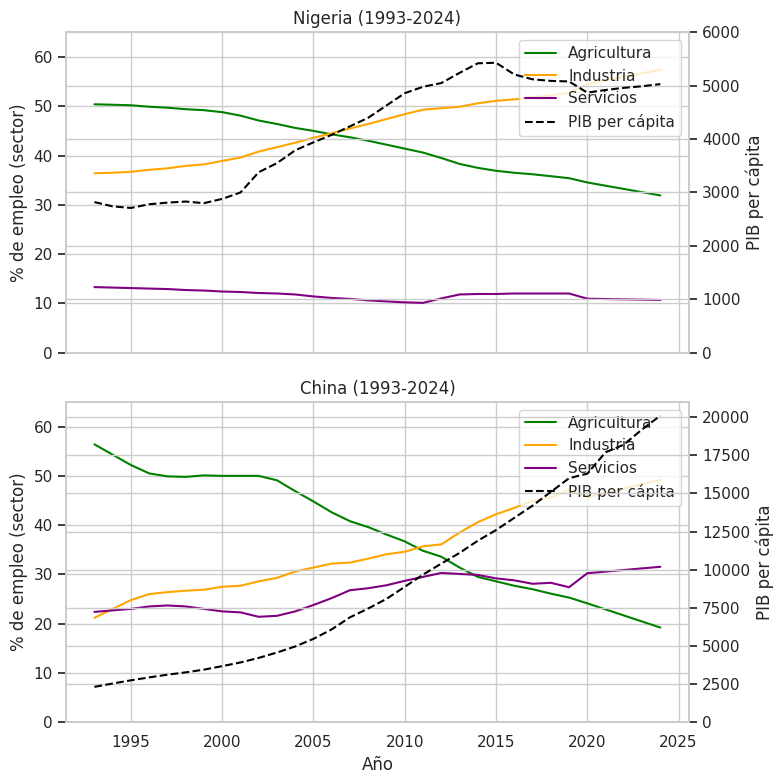

In [48]:
df_nigeria = df[df['country']=='Nigeria'].sort_values('year')
df_china   = df[df['country']=='China'].sort_values('year')

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8,8), sharex=True)

ax1 = axes[0]
ax1.plot(df_nigeria['year'], df_nigeria['%_trabaj_agricult'], color='green', label='Agricultura')
ax1.plot(df_nigeria['year'], df_nigeria['%_trabaj_industria'], color='orange', label='Industria')
ax1.plot(df_nigeria['year'], df_nigeria['%_trabaj_servicios'], color='purple', label='Servicios')
ax1.set_ylabel("% de empleo (sector)")
ax1.set_title("Nigeria (1993-2024)")
ax1_right = ax1.twinx()
ax1_right.plot(df_nigeria['year'], df_nigeria['pib_pcapita'], color='black', linestyle='--', label='PIB per cápita')
ax1_right.set_ylabel("PIB per cápita")
ax1.set_ylim(0, 65)
ax1_right.set_ylim(0, 6000)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')

ax2 = axes[1]
ax2.plot(df_china['year'], df_china['%_trabaj_agricult'], color='green', label='Agricultura')
ax2.plot(df_china['year'], df_china['%_trabaj_industria'], color='orange', label='Industria')
ax2.plot(df_china['year'], df_china['%_trabaj_servicios'], color='purple', label='Servicios')
ax2.set_xlabel("Año")
ax2.set_ylabel("% de empleo (sector)")
ax2.set_title("China (1993-2024)")
ax2_right = ax2.twinx()
ax2_right.plot(df_china['year'], df_china['pib_pcapita'], color='black', linestyle='--', label='PIB per cápita')
ax2_right.set_ylabel("PIB per cápita")

ax2.set_ylim(0, 65)
ax2_right.set_ylim(0, 21000)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout()
plt.show()

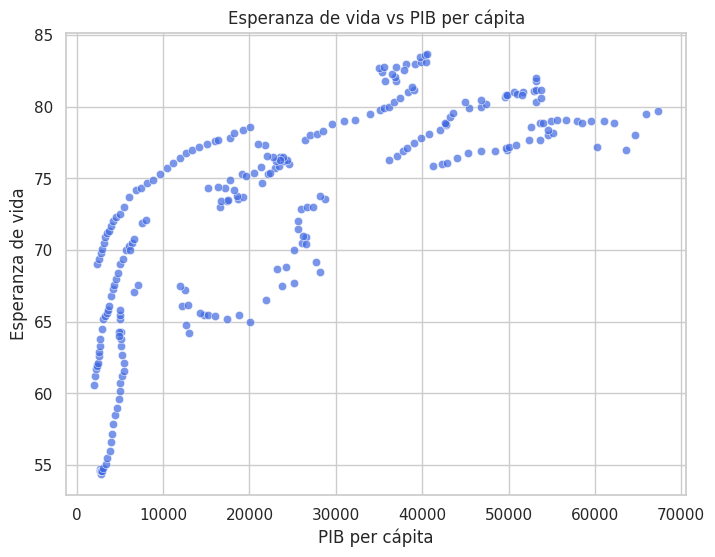

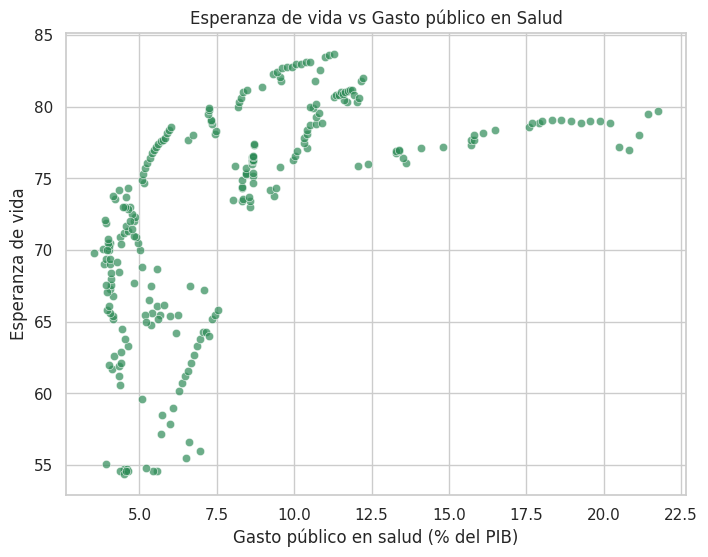

In [ ]:
import pandas as pd
import numpy as np


df['GDPpc_quartile'] = pd.qcut(df['pib_pcapita'], q=4,
                               labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])

health_col = 'gasto_publ_total_en_salud_% _pib '
df['HealthExp_quartile'] = pd.qcut(df[health_col], q=4,
                                   labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])

life_median = df['esper_de_vida'].median()
gdp_median = df['pib_pcapita'].median()
df['LifeExp_cat'] = np.where(df['esper_de_vida'] >= life_median, 'Alta', 'Baja')
df['GDPpc_cat'] = np.where(df['pib_pcapita'] >= gdp_median, 'Alto', 'Bajo')


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pib_pcapita', y='esper_de_vida', color='royalblue', alpha=0.7)
plt.title('Esperanza de vida vs PIB per cápita')
plt.xlabel('PIB per cápita')
plt.ylabel('Esperanza de vida')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=health_col, y='esper_de_vida', color='seagreen', alpha=0.7)
plt.title('Esperanza de vida vs Gasto público en Salud')
plt.xlabel('Gasto público en salud (% del PIB)')
plt.ylabel('Esperanza de vida')
plt.grid(True)
plt.show()



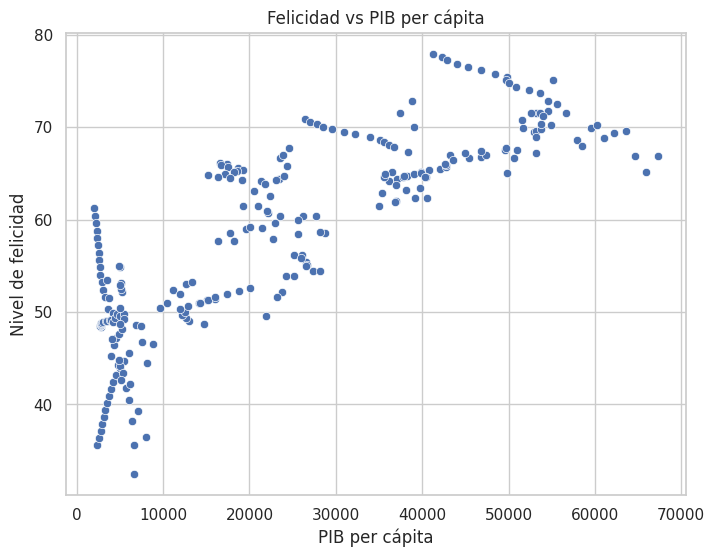

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pib_pcapita', y='nivel_de_felicidad')
plt.xlabel('PIB per cápita')
plt.ylabel('Nivel de felicidad')
plt.title('Felicidad vs PIB per cápita')
plt.show()


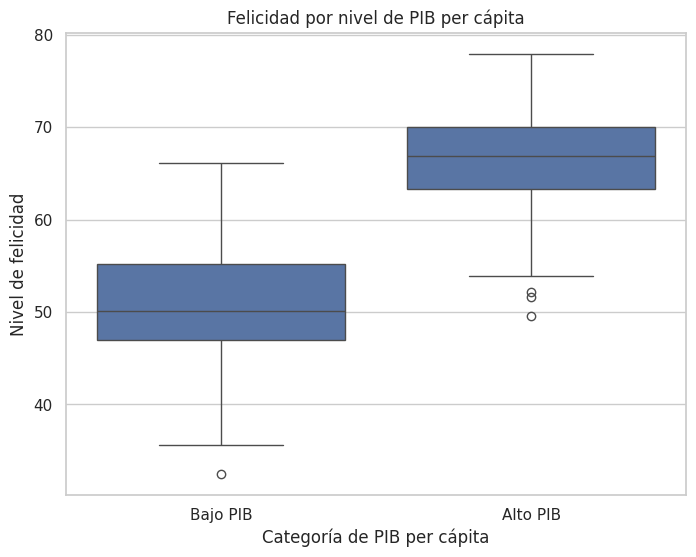

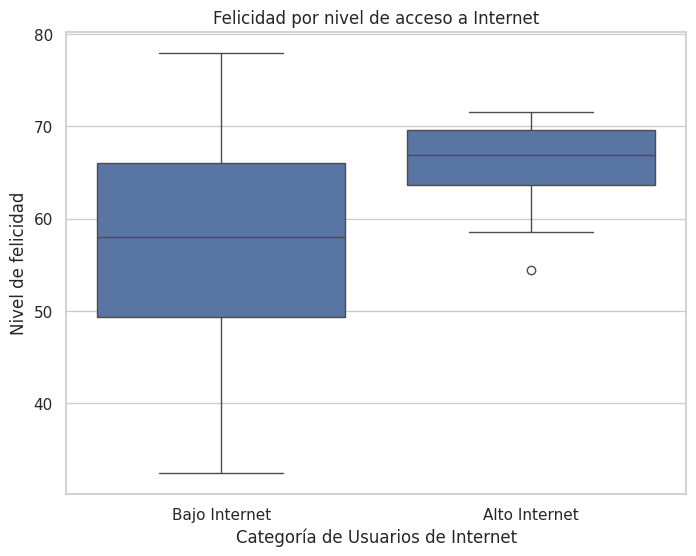

In [ ]:
import numpy as np

median_pib = df['pib_pcapita'].median()
df['nivel_pib'] = df['pib_pcapita'].apply(lambda x: 'Alto PIB' if x > median_pib else 'Bajo PIB')
median_int = last5['%_usuarios_internet'].median()
df['nivel_int'] = df['%_usuarios_internet'].apply(lambda x: 'Alto Internet' if x > median_int else 'Bajo Internet')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='nivel_pib', y='nivel_de_felicidad')
plt.xlabel('Categoría de PIB per c\u00e1pita')
plt.ylabel('Nivel de felicidad')
plt.title('Felicidad por nivel de PIB per c\u00e1pita')
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='nivel_int', y='nivel_de_felicidad')
plt.xlabel('Categoría de Usuarios de Internet')
plt.ylabel('Nivel de felicidad')
plt.title('Felicidad por nivel de acceso a Internet')
plt.show()
